#### Analysis Notebook for Radio Star Calibration of Big Dish

dsheen draft 2025-10-14

The following is a notebook for analysis of a scan of Cassiopeia A* using scan_radio_star.py. Over the course of the notebook we will import the log files, perform rfi-robust processing of the measured data, and use the result to estimate calibrator curves and the telescope sensitivity over the protected band.

The results of this analysis for a known reference star can then be used to perform wideband correction of scans of other measurements.

## 1. Manual Generation of Radio Star Flux Curves

In [86]:
import matplotlib.pyplot as plt
import os
import sys
import csv
from datetime import datetime, timezone
import numpy as np
import scipy as sc
import pandas as pd
import astropy.units as u
import astropy.constants as const

from astropy.time import Time
from astropy.coordinates import SkyCoord
from astropy.coordinates import ICRS
from astropy.coordinates import GCRS
from astropy.coordinates import Galactic

from astroplan import Observer

### Create a Nice Dictionary of Radio Stars we have Good Published Measurements for
use sources from

"An Accurate Flux Density Scale from 50MHz to 50GHz"

R. A. Perley and B. J. Butler National Radio Astronomy Observatory, P.O. Box O, Socorro, NM 87801, USA; RPerley@nrao.edu, BButler@nrao.edu

https://iopscience.iop.org/article/10.3847/1538-4365/aa6df9/pdf

so that we know we have good flux models for them. Only use relatively bright ones that are easy to find. Also save flux coefficents for them from table 6 so we can use this equation

$log(S)=a_0 +a_1log(f)+a_2[log(f)]^2 +a_3[log(f)]^3+ $.... for f in GHz and S in Jy

In [2]:
radio_stars = {}

radio_stars['3C48'] = {'coords':(24.42208192967, 33.15974455245), 
                       'coefficients' : np.array([1.3253, -0.7553,-0.1914,0.0498])}

radio_stars['FornaxA'] = {'coords':(50.6741208, -37.2082), 
                       'coefficients' : np.array([2.2175, -0.6606])}

radio_stars['3C123'] = {'coords':(69.26823064375, 29.67050498975), 
                       'coefficients' : np.array([1.8017, -0.7884, -0.1035, -0.0248, 0.0090])}

radio_stars['3C138'] = {'coords':(80.29119151075, 16.63945876275), 
                       'coefficients' : np.array([1.0088, -0.4981, -0.1552, -0.0102, 0.0223])}

radio_stars['PictorA'] = {'coords':(79.95717888494, -45.77884796187), 
                       'coefficients' : np.array([1.9380, -0.7470, -0.0739])}

radio_stars['TaurusA'] = {'coords':(83.6324, 22.0174), 
                       'coefficients' : np.array([2.9516, -0.2173, -0.0473, -0.0674]),
                    'beamwidth_correction' : 4.6}

radio_stars['3C147'] = {'coords':(85.65057457125, 49.852009364972), 
                       'coefficients' : np.array([1.4516, -0.6961, -0.2007, 0.0640, -0.0464, 0.0289])}

radio_stars['3C196'] = {'coords':(123.40023382088, 48.21740137945), 
                       'coefficients' : np.array([1.2872, -0.8530, -0.1534, -0.0200, 0.0201])}

radio_stars['HydraA'] = {'coords':(139.52361869175, -12.095501689528), 
                       'coefficients' : np.array([1.7795, -0.9176, -0.0843, -0.0139, 0.0295])}

radio_stars['VirgoA'] = {'coords':(187.70593076725, 12.391123246083), 
                       'coefficients' : np.array([2.4466, -0.8116, -0.0483]),
                         'beamwidth_correction' : 2.5}

radio_stars['3C286'] = {'coords':(202.78453479432, 30.50915558099), 
                       'coefficients' : np.array([1.2481, -0.4507, -0.1798, 0.0357])}

radio_stars['3C295'] = {'coords':(212.836, 52.2025), 
                       'coefficients' : np.array([1.4701, -0.7658, -0.2780, -0.0347, 0.0399])}

radio_stars['HerculesA'] = {'coords':(252.78328611990997, 4.99320753652), 
                       'coefficients' : np.array([1.8298, -1.0247, -0.0951])}

radio_stars['3C353'] = {'coords':(260.11736689063, -0.9796062372), 
                       'coefficients' : np.array([1.8627, -0.6938, -0.0998, -0.0732])}

radio_stars['3C380'] = {'coords':(277.38242072207, 48.74615560247), 
                       'coefficients' : np.array([1.2320, -0.7909, 0.0947, 0.0976, -0.1794, -0.1566])}

radio_stars['CygnusA'] = {'coords':(299.868152368208, 40.733915897917), 
                       'coefficients' : np.array([3.3498, -1.0022, -0.2246, 0.0227, 0.0425]),
                         'beamwidth_correction' : 2.5}

radio_stars['3C444'] = {'coords':(333.6073, -17.0267472), 
                       'coefficients' : np.array([1.1064, -1.0052, -0.0750, -0.0767])}

radio_stars['CassiopeiaA'] = {'coords':(350.8584, 58.8113), 
                        'coefficients' : np.array([3.3584, -0.7518, -0.0347, -0.0705]),
                        'beamwidth_correction' : 4.6}

radio_stars['Orion'] = {'coords':(83.8201, -5.3876), 
                       'coefficients' : np.array([2.705, -0.204]),
                       'beamwidth_correction' : 4.6}

In [376]:
def get_flux(star,f):
    '''
    star: str, name of star correcponding to dictinary entry key
    f: frequency or frequencies at which to compute flux
    '''
    
    a = radio_stars[star]['coefficients']
    logfreq = np.log10(f.to(u.GHz).value)
    
    
    logS = np.zeros_like(logfreq)
    for i in range(len(a)):
        logS += a[i]*np.power(logfreq,i)

    S = np.power(10,logS)*u.Jy
    return S

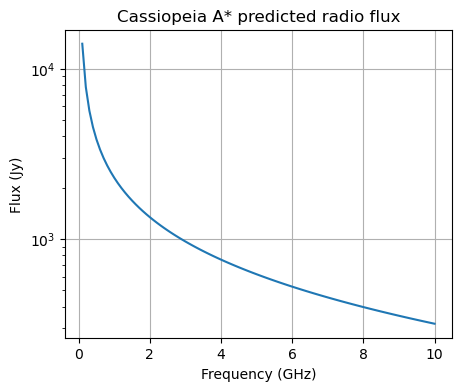

In [385]:
freqs = np.linspace(0.1,10,100)*u.GHz

flux = get_flux('CassiopeiaA',freqs)#*get_cas_A_C3(2025, freqs)

plt.figure()
plt.semilogy(freqs,flux)
plt.ylabel("Flux (Jy)")
plt.xlabel("Frequency (GHz)")
plt.title("Cassiopeia A* predicted radio flux")
plt.grid()
plt.show()

### Antenna Parameters and Corrections

from the corrections in RECOMMENDATION ITU-R S.733-2

$\frac{G}{T} = \frac{8\pi k (r-1)}{\lambda^2 \Phi(f)}$

where $r = \frac{P_n + P_{st}}{P_n} = \frac{T_{sys} + T_{st}}{T_{sys}}$ and $\Phi(f)$ is the flux in $Wm^{-2}Hz^{-1}$ 


corrrection factor C2 is included for the angular extent of radio stars vs the beam width in equation 3

$(G/ T)_c = G/T + C1 + C2 + C3$

where C3 is only applicable to Cas A, C1 is a correction for atmospheric loss (which we shall ignore because I typically count that as part of G/T) and so C2 is the only thing that matters


$C2 \approx -10log_{10}\left[\frac{ABS \left( 1-e^{-\chi^2} \right)}{\chi^2}\right]$ in dB

where $\chi_{CygA} \approx \frac{2.5}{1.2012 \theta_{3dB} \times 60}$

and $\chi_{most other things} \approx \frac{4.6}{1.2012 \theta_{3dB} \times 60}$

and C3 is given as 

$C_3 = -10 log_{10} \left[1-\frac{0.97 - 0.3 log_{10}(f)}{100}\right]^n$

where n is years since january 1980.



In [379]:
def get_C2(star,Theta):
    '''
    star is name of star in dictionary
    Theta is half power beamwidth in degrees
    freq is frequency
    
    '''
    Chi = radio_stars[star]['beamwidth_correction']/(1.2012*Theta.to(u.degree).value*60)
    C2 = -10*np.log10(np.abs(1-np.exp(-Chi**2))/Chi**2)
    return C2

def get_cas_A_C3(year, freq):
    '''
    year is what year it is now
    
    '''
    C3_lin = (1 - (0.97 - 0.3 *np.log10(freq.to(u.GHz).value))/100)**(year - 1980)
    return C3_lin

## 2. Coordinate converter definitions needed for antenna elevation response corrections

In [87]:
#antenna location

antennas ={
            "westford" : 
                {
                "slew_time" : 60,
                "min_elevation" : 5.0, # idk what this was just remeber it isn't really quite down to the horizon normally
                "max_elevation" : 87.0,
                "coords_wgs84" : 
                    {
                    "lat" : 42.61295,
                    "lon" : -71.49379,
                    "el" : 86.76897,
                    },
                },
            "bigdish" : 
                {
                "slew_time" : 30,
                "min_elevation" : 0.0,
                "max_elevation" : 87.0,
                "coords_wgs84" : 
                    {
                    "lat" : 42.360236,
                    "lon" : -71.089478,
                    "el" : 97.0,
                    },
                },
            }

#add full coordinate objects after instantiating dict (this just feels neater that the other way I might do it)
#for antenna in antennas:
#    coords = antennas[antenna]["coords_wgs84"]
#    antennas[antenna]['coord_obj'] = wgs84.latlon(coords["lat"], coords["lon"], coords["el"])


In [88]:
## observer definition

radome_observer = Observer(
    latitude = antennas["bigdish"]["coords_wgs84"]["lat"]*u.degree, 
    longitude = antennas["bigdish"]["coords_wgs84"]["lon"]*u.degree, 
    elevation = antennas["bigdish"]["coords_wgs84"]["el"]*u.m, 
    name = 'radome')

In [90]:
## frame definitions

#azel_frame = radome_observer.altaz(observation_time)
icrs_frame = ICRS()

In [91]:
## converter definition

def radec_to_azel(t0, ra_pos, ra_vel, dec_pos, dec_vel):
        t0 = Time(t0, format = "unix")

        #convert right ascension and declination vector to azimuth and elevation vector
        #we do this by computing it one second ahead to get the velocities
        
        pos_icrs = SkyCoord(ra = ra_pos * u.degree, 
                            dec = dec_pos * u.degree, 
                            frame = icrs_frame)
        next_pos_icrs = SkyCoord(ra = ra_pos * u.degree + ra_vel * u.degree, 
                                 dec = dec_pos * u.degree + dec_vel * u.degree, 
                                 frame = icrs_frame)
        #self.update_azel()
        pos_azel = pos_icrs.transform_to(radome_observer.altaz(t0))
        next_pos_azel = next_pos_icrs.transform_to(radome_observer.altaz(t0 + 1 * u.s))

        return {"az_pos": pos_azel.az.degree, 
                "az_vel": next_pos_azel.az.degree - pos_azel.az.degree, 
                "el_pos": pos_azel.alt.degree, 
                "el_vel": next_pos_azel.alt.degree-pos_azel.alt.degree}

## 3. Import Log Data from Scan of Radio Star

Before we can do anything with the actual RF samples, we need to know where the telescope was pointed at what time and what the calibrator states were. for this we need to ingest and process the log file since we do not yet have a mechanism for adding this to the drf metadata during the recording.

the size of the files makes it impractical to keep any in the github so you will need to get your own. the DRF top directory and the logfile should be in the same folder

In [6]:
import os
import sys
import csv
from datetime import datetime, timezone
import numpy as np
import pandas as pd

### Get File Information

In [10]:
#observation directory path
#observation_directory = "/home/dsheen/temp_rf_data/cygnusA_2025-10-01_scan/"
#observation_directory = "/data/cygnus_2025-10-01"
#observation_directory = "/data/dsheen/Bigdish_cygnusA_2025-10-01"
observation_directory = "/data/cas_2025-10-05_pass3"

In [11]:
#grab logfile and drf file paths
files = os.listdir(observation_directory)

for file in files:
    if file.split('.')[-1] == 'log':
        logfile = file
        print(f"found log file {logfile}")
    else: #see if it's the drf directory
        try:
            subdirs = os.listdir(os.path.join(observation_directory, file))
            if 'LHCP' in subdirs or 'RHCP' in subdirs: #then this is probably the drf top directory
                drf_directory = file
                print(f"found drf directory {drf_directory}")
        except:
            print(f"skipping {file}. File does not appear to be digital_rf or logfile.")

found log file 2025-10-05T22:59:00.039978Z_radec_350.86_58.82.log
skipping Active_satellites_2025-10-05_evening.tle. File does not appear to be digital_rf or logfile.
found drf directory casA_2025-10-05_take3


### Read in the log data

In [94]:
scan_target_commands = []
scan_settling_times = []
scan_calibrator_transitions = []
telescope_positions = []

with open(os.path.join(observation_directory,logfile), 'r') as file:
    logdata = csv.reader(file)

    for row in logdata:
        #splitup by info type and save into python variables and lists

        #####################
        # header info
        #####################
        if row[0].strip() == "scan_coords":
            scan_coord_frame = row[1].strip() #coordinate system
        elif row[0].strip() == "scan_center":
            scan_center = np.array([float(row[i].strip()) for i in range(1,len(row))]) #scan center point
        elif row[0].strip() == "extents":
            extents = np.array([float(row[i].strip()) for i in range(1,len(row))]) #max range of scan from center point
        elif row[0].strip() == "steps":
            steps = np.array([float(row[i].strip()) for i in range(1,len(row))]) #step between points in both axes
        elif row[0].strip() == "num_points":
            num_points = int(row[1].strip()) #number of points in scan
        elif row[0].strip() == "integration_time":
            integration_time = float(row[1].strip()) #time in seconds to integrate after calibration period
        elif row[0].strip() == "cal_time":
            cal_time = float(row[1].strip()) #time for calibrator to be enabled on each channel

        ##########################
        # actual scan timing data
        ##########################
        elif row[0].strip() == "target_point":
            #append command time and coordinates
            scan_target_commands.append({'time': datetime.fromisoformat((row[1].strip()).replace('Z', '+00:00')), 
                                         'pos' : np.array([float(row[3].strip()),float(row[4].strip())])})

        elif row[0].strip() == "position":
            #telescope reported position time, coords, velocities
            telescope_positions.append({'time': datetime.fromisoformat((row[1].strip()).replace('Z', '+00:00')), 
                                        'pos' : np.array([float(row[2].strip()),float(row[3].strip())]), 
                                        'vel' : np.array([float(row[4].strip()),float(row[5].strip())])})
        elif row[0].strip() == "settled":
            #time when telescope has settled to target point
            scan_settling_times.append(datetime.fromisoformat((row[1].strip()).replace('Z', '+00:00')))
        elif row[0].strip() == "calibrator_state":
            #calibrator state timing info
            scan_calibrator_transitions.append({'time': datetime.fromisoformat((row[1].strip()).replace('Z', '+00:00')),
                                                'state': int(row[2].strip())})
        else: #something weird happened
            print(f"unrecognized line starting with {row[0].strip()}! Is file correct?")



print(f"scan contains {num_points} points centered about {scan_coord_frame} coordinates {scan_center}")
#telescope_positions = pd.DataFrame(telescope_positions)
#print(telescope_positions)

scan contains 22 points centered about radec coordinates [350.859  58.811]


### Manipulate this into a nicer format with a signle entry for each point telling us what segments of data are what

In [95]:
scan_points_info = []

#get an array of position timestamps for subsequent use
telescope_position_times = np.array([point['time'].timestamp() for point in telescope_positions])
telescope_position_coords = np.array([point['pos'] for point in telescope_positions])

def get_pointing_time_inices(bounds):
    tmin = bounds[0].timestamp()
    tmax = bounds[1].timestamp()
    imin = np.where(telescope_position_times>=tmin)[0][0]
    imax = np.where(telescope_position_times>=tmax)[0][0]
    return imin,imax

def get_mean_pointing_error(bounds, point):
    """return telescope mean error fromm target"""
    imin,imax = get_pointing_time_inices(bounds)
    positions = telescope_position_coords[imin:imax]
    errors = np.sqrt(np.sum(np.power(positions - point,2),axis=1))
    
    return np.mean(errors)


for i in range(num_points):
    scan_target_coords = scan_target_commands[i]["pos"]
    settling_time = scan_settling_times[i]
    cal_info = scan_calibrator_transitions[3*i:3*i+3]

    if i+1 ==num_points:
        end_time = telescope_positions[-1]["time"]
    else:
        end_time = scan_target_commands[i+1]["time"]

    cal_1_bounds = [cal_info[0]['time'], cal_info[1]['time']]
    cal_2_bounds = [cal_info[1]['time'], cal_info[2]['time']]
    cal_off_bounds = [cal_info[2]['time'], end_time]

    #get nominal pointing errors for these time ranges
    
    #cal1_timestamps 

    scan_points_info.append({'pos' : scan_target_coords,
                             'cal_1_bounds' : cal_1_bounds,
                             'cal_2_bounds' : cal_2_bounds,
                             'cal_off_bounds' : cal_off_bounds,
                             'cal_1_pos_error' : get_mean_pointing_error(cal_1_bounds, scan_target_coords),
                             'cal_2_pos_error' : get_mean_pointing_error(cal_2_bounds, scan_target_coords),
                             'cal_off_pos_error' : get_mean_pointing_error(cal_off_bounds, scan_target_coords),
                            })
    
scan_points_info = pd.DataFrame(scan_points_info)

print(scan_points_info.iloc[int(num_points/2)])

pos                                                  [346.135, 62.585]
cal_1_bounds         [2025-10-05 23:08:36+00:00, 2025-10-05 23:08:4...
cal_2_bounds         [2025-10-05 23:08:46+00:00, 2025-10-05 23:08:5...
cal_off_bounds       [2025-10-05 23:08:56+00:00, 2025-10-05 23:09:0...
cal_1_pos_error                                                0.16088
cal_2_pos_error                                               0.148234
cal_off_pos_error                                             0.241382
Name: 11, dtype: object


## 4. Digital RF data import and processing

pull in drf data, get metadata about frequency, sample rate etc. And process the data for each point into spectra for the different calibrator states 

In [16]:
import digital_rf as drf
import multiprocessing
from functools import partial

### Start by getting metadata

In [17]:
rf_data_path = os.path.join(observation_directory,drf_directory)
channels = ["RHCP","LHCP"]

In [18]:
dio = drf.DigitalRFReader(rf_data_path)
sr = dio.get_properties(channels[0])["samples_per_second"]
bounds = dio.get_bounds(channels[0])

dt_start = datetime.fromtimestamp(float(bounds[0] / sr), tz=timezone.utc,)
dt_stop = datetime.fromtimestamp(float(bounds[1] / sr), tz=timezone.utc)

metadata = dio.read_metadata(bounds[0],bounds[0]+1, channels[0])
metadata_key = list(metadata.keys())[0]
radio_metadata = metadata[metadata_key]
cf = radio_metadata['center_frequencies'][0]

print(f"Digital RF data has bounds {dt_start.isoformat()}, {dt_stop.isoformat()}")
print(f"sample rate {sr/1e6} MHz, center frequency {cf/1e6} MHz")

Digital RF data has bounds 2025-10-05T22:58:54+00:00, 2025-10-05T23:18:39+00:00
sample rate 25.0 MHz, center frequency 1413.5 MHz


### User Settings for spectrum slicing

In [19]:
num_frequency_points = 512

slicelen = 0.1 #approx fft slice time in seconds for the fft computation to not be truly ridiculous 
#will be averaged anyway so just a computation efficincy thing
num_processes = 16

### Define a not completely insane multithreaded FFT processor

In [20]:
def calculate_welch_slice(channel, samples_per_slice, start_sample):
        '''
        Calculate the welch method spectrogram for the given data slice
        '''

        try:
            data = dio.read_vector(
                start_sample, samples_per_slice, channel, 0
            )
        except IOError:
            print(
                "IO Error for channel {0}:{1} start sample {2}".format(
                    channel,
                    start_sample,
                )
            )
            # handle data gaps better
            data = np.empty(samples_per_slice, np.complex64)
            data[:] = np.nan

        #actually handle the welch operation

        try:
            freq_axis, psd_data = sc.signal.welch(
                data,
                fs=float(sr),
                nperseg=num_frequency_points,
                detrend=False,
                scaling="density",
                return_onesided=False,
                average='median'
            )
        except Exception:
            traceback.print_exc(file=sys.stdout)

        #sti_psd_data = np.real(
        #    10.0 * np.log10(np.abs(sc.fft.fftshift(psd_data)) + 1e-20)
        #    )  # 1e-20 is added to prevent divide by zero issues with logarithm

        
        sti_psd_data = np.real(np.abs(sc.fft.fftshift(psd_data)))
        #how the time of the slice is defined is perhaps open to debate
        sti_time = (start_sample + samples_per_slice / 2) / sr
        #sti_time = (start_sample) / self.sample_rate

        return sti_psd_data, sc.fft.fftshift(freq_axis), sti_time

def process_data_spectrum(start_sample, end_sample, channel):
    samples_per_slice = int(sr*slicelen/num_frequency_points)*num_frequency_points
    start_samples = np.arange(start_sample,end_sample,samples_per_slice)

    pool = multiprocessing.Pool(processes=num_processes)
    welch_slice = partial(calculate_welch_slice, channel, samples_per_slice)

    outputs = pool.map(welch_slice, start_samples)

    pool.close()
    pool.join()

    sti_psd_data = outputs[0][0]
    freq_axis = outputs[0][1]

    for i in range(1,len(start_samples)):
        sti_psd_data += outputs[i][0]

    sti_psd_data = sti_psd_data/len(start_samples)
    return sti_psd_data, freq_axis

### Process spectra for each point

In [21]:
point_spectra = []

for i in range(num_points):
    print(f" working on point {i}")
    point_info = scan_points_info.iloc[i]
    
    cal_timing_margin = 0.01
    cal_1_sample_bounds = [int(point_info['cal_1_bounds'][0].timestamp()*sr + cal_timing_margin*sr),
                            int(point_info['cal_1_bounds'][1].timestamp()*sr - cal_timing_margin*sr)]
    cal_2_sample_bounds = [int(point_info['cal_2_bounds'][0].timestamp()*sr + cal_timing_margin*sr),
                            int(point_info['cal_2_bounds'][1].timestamp()*sr - cal_timing_margin*sr)]
    cal_off_sample_bounds = [int(point_info['cal_off_bounds'][0].timestamp()*sr + cal_timing_margin*sr),
                            int(point_info['cal_off_bounds'][1].timestamp()*sr - cal_timing_margin*sr)]
    
    # just hard code this because it makes building the arrays a little easier
    RHCP_cal_1_psd, freq_axis = process_data_spectrum(cal_1_sample_bounds[0], cal_1_sample_bounds[1], channels[0])
    RHCP_cal_2_psd, freq_axis = process_data_spectrum(cal_2_sample_bounds[0], cal_2_sample_bounds[1], channels[0])
    RHCP_cal_off_psd, freq_axis = process_data_spectrum(cal_off_sample_bounds[0], cal_off_sample_bounds[1],channels[0])

    LHCP_cal_1_psd, freq_axis = process_data_spectrum(cal_1_sample_bounds[0], cal_1_sample_bounds[1], channels[1])
    LHCP_cal_2_psd, freq_axis = process_data_spectrum(cal_2_sample_bounds[0], cal_2_sample_bounds[1], channels[1])
    LHCP_cal_off_psd, freq_axis = process_data_spectrum(cal_off_sample_bounds[0], cal_off_sample_bounds[1],channels[1])

    point_spectra.append({"frequencies" : freq_axis + cf,
                          "RHCP" : [RHCP_cal_off_psd, RHCP_cal_1_psd, RHCP_cal_2_psd],
                          "LHCP" : [LHCP_cal_off_psd, LHCP_cal_1_psd, LHCP_cal_2_psd]})

point_spectra = pd.DataFrame(point_spectra)

 working on point 0
 working on point 1
 working on point 2
 working on point 3
 working on point 4
 working on point 5
 working on point 6
 working on point 7
 working on point 8
 working on point 9
 working on point 10
 working on point 11
 working on point 12
 working on point 13
 working on point 14
 working on point 15
 working on point 16
 working on point 17
 working on point 18
 working on point 19
 working on point 20
 working on point 21


In [23]:
#save this so we don't always need to reprocess it if I close the notebook
point_spectra.to_pickle(os.path.join(observation_directory, "saved_spectra.pkl"))

### Plot Spectra to verify they look OK

note our gain actually seems to be rather wavy prior to correction. this is normal and appears to be a result of effects following the telescope frontend ratehr than anything to do with the feed or LNAs. It does not seem to effect sensitivity and it appears to be repeatable in time (albeit I have yet to explore the effects of different radio settings)

In [24]:
point_spectra = pd.read_pickle(os.path.join(observation_directory, "saved_spectra.pkl"))

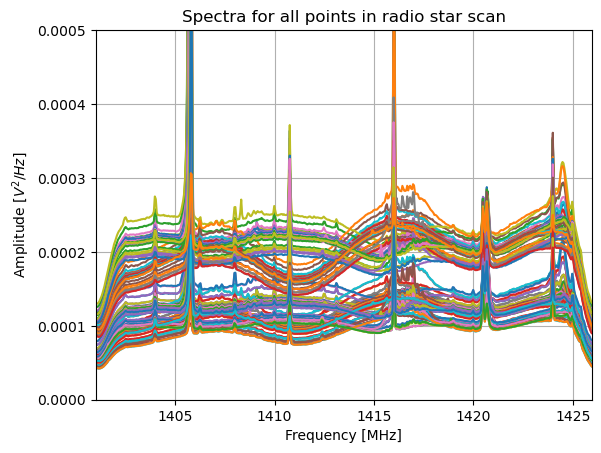

In [25]:
plt.figure()
for j in range(len(point_spectra)):
    for i in range(3):
        plt.plot(point_spectra['frequencies'][j]/1e6,point_spectra['RHCP'][j][i])
        plt.plot(point_spectra['frequencies'][j]/1e6,point_spectra['LHCP'][j][i])

plt.title("Spectra for all points in radio star scan")
plt.ylim([0,0.0005])
plt.ylabel(r"Amplitude $[V^2/Hz]$")
plt.xlim([point_spectra.iloc[0]['frequencies'][0]/1e6, point_spectra.iloc[0]['frequencies'][-1]/1e6])
plt.xlabel("Frequency [MHz]")
plt.grid()
plt.show()

## 5. Baseline flattening and initial calibrator shape estimation


Estimate the shape of the calibrator response for both channels averaged across the entire measurement. Then normalize the measurement by this curve to eliminate the passband ripple.

note we do get the 3dB filter rolloff at the band edge like we should expect, and the calibrators appear to actually be quite good at rejecting most RFI are actualy extremely good at rejecting any of the rfi we see. Almost none of the RFI appears in the estimated calirator response save for asignal near 1.405 GHz. That frequency appears to be unusable for measurements anyway so it doesn't matter much

In [30]:
### get calibrator deltas for all points and average
RHCP_cal = []
LHCP_cal = []

for i in range(num_points):

    RHCP_cal.append(point_spectra['RHCP'][i][1]- point_spectra['RHCP'][i][0])
    LHCP_cal.append(point_spectra['LHCP'][i][2]- point_spectra['LHCP'][i][0])

RHCP_cal = np.median(np.array(RHCP_cal),axis=0)
LHCP_cal = np.median(np.array(LHCP_cal),axis=0)

#RHCP_cal = np.mean(np.array(RHCP_cal),axis=0)
#LHCP_cal = np.mean(np.array(LHCP_cal),axis=0)

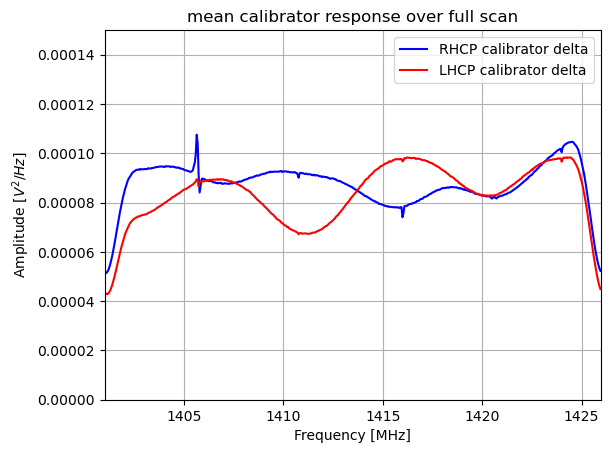

In [31]:
plt.figure()
#for j in range(len(point_spectra)):
    #for i in range(3):
plt.plot(point_spectra['frequencies'][0]/1e6,RHCP_cal,color='blue', label='RHCP calibrator delta')
plt.plot(point_spectra['frequencies'][0]/1e6,LHCP_cal,color='red', label='LHCP calibrator delta')

plt.title("mean calibrator response over full scan")
plt.ylim([0,0.00015])
plt.ylabel(r"Amplitude $[V^2/Hz]$")
plt.xlim([point_spectra.iloc[0]['frequencies'][0]/1e6, point_spectra.iloc[0]['frequencies'][-1]/1e6])
plt.xlabel("Frequency [MHz]")
plt.legend()
plt.grid()
plt.show()


### Normalize calibrator delta to unity across all frequencies and plot

Mostly this is to simplify later math since it's one fewer varying terms, but also this is a good check of whether the above ripple is from the calibrator or the gains after it. If it's purely gain ripple and the cal is relatively flat, then we should expect scaling by it to remove the ripple from both the cal signal and baseline, which is for the most part what we see.

In [34]:
normalized_spectra = []

for i in range(num_points):
    point = point_spectra.iloc[i]
    # just hard code this because it makes building the arrays a little easier
    RHCP_cal_1_psd = point['RHCP'][1]/RHCP_cal
    RHCP_cal_2_psd = point['RHCP'][2]/RHCP_cal
    RHCP_cal_off_psd = point['RHCP'][0]/RHCP_cal

    LHCP_cal_1_psd = point['LHCP'][1]/LHCP_cal
    LHCP_cal_2_psd = point['LHCP'][2]/LHCP_cal
    LHCP_cal_off_psd = point['LHCP'][0]/LHCP_cal

    normalized_spectra.append({"frequencies" : point['frequencies'],
                          "RHCP" : np.array([RHCP_cal_off_psd, RHCP_cal_1_psd, RHCP_cal_2_psd]),
                          "LHCP" : np.array([LHCP_cal_off_psd, LHCP_cal_1_psd, LHCP_cal_2_psd])})

normalized_spectra = pd.DataFrame(normalized_spectra)

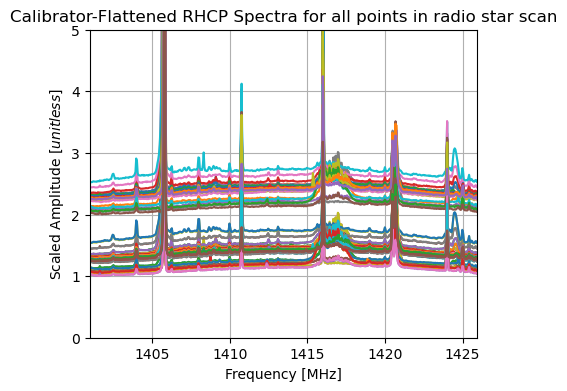

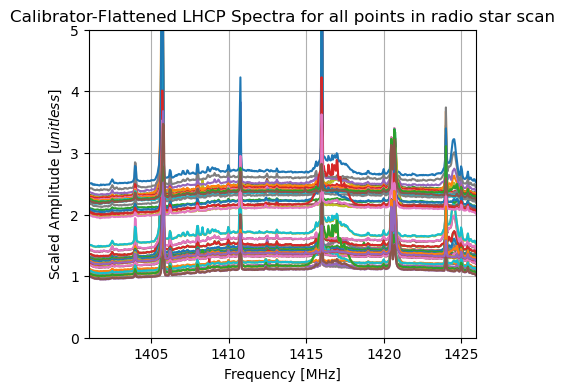

In [107]:
plt.figure()
for j in range(len(normalized_spectra)):
    for i in range(3):
        plt.plot(normalized_spectra['frequencies'][j]/1e6,normalized_spectra['RHCP'][j][i])
        #plt.plot(point_spectra['frequencies'][j]/1e6,point_spectra['LHCP'][j][i]/LHCP_cal)

plt.title("Calibrator-Flattened RHCP Spectra for all points in radio star scan")
plt.ylim([0,5])
plt.ylabel(r"Scaled Amplitude $[unitless]$")
plt.xlim([normalized_spectra.iloc[0]['frequencies'][0]/1e6, normalized_spectra.iloc[0]['frequencies'][-1]/1e6])
plt.xlabel("Frequency [MHz]")
plt.grid()
plt.show()

plt.figure()
for j in range(len(normalized_spectra)):
    for i in range(3):
        #plt.plot(point_spectra['frequencies'][j]/1e6,point_spectra['RHCP'][j][i]/RHCP_cal)
        plt.plot(normalized_spectra['frequencies'][j]/1e6,normalized_spectra['LHCP'][j][i])

plt.title("Calibrator-Flattened LHCP Spectra for all points in radio star scan")
plt.ylim([0,5])
plt.ylabel(r"Scaled Amplitude $[unitless]$")
plt.xlim([normalized_spectra.iloc[0]['frequencies'][0]/1e6, normalized_spectra.iloc[0]['frequencies'][-1]/1e6])
plt.xlabel("Frequency [MHz]")
plt.grid()
plt.show()

Note that we see the interferer between 1415 and 1418 MHz very prominently in this plot. 

The fact that the spectrum is not quite flat likely implies that the calibrator response is not truly flat across the telescope bandwidth. 

## 6. RFI Mask Generation

detect and exclude RFI that is significantly non-constant across the different measurement locations by looking at its variance

In [108]:
#for some reason the pandas to_numpy() method dooesn't work here so need to forcibly get these into numpy arrays
#in hidsight perhaps it was a poor choice of data structure 

RHCP_data = []
LHCP_data = []
positions = []

for i in range(num_points):
    point = normalized_spectra.iloc[i]
    # just hard code this because it makes building the arrays a little easier
    RHCP_data.append(point['RHCP'])
    LHCP_data.append(point['LHCP'])
    positions.append(scan_points_info['pos'][i])

RHCP_data = np.swapaxes(np.array(RHCP_data),0,1).reshape(3,num_points, num_frequency_points)
LHCP_data = np.swapaxes(np.array(LHCP_data),0,1).reshape(3,num_points, num_frequency_points)
positions = np.swapaxes(np.array(positions),0,1)
print(f" array shape: {np.shape(RHCP_data)}")

 array shape: (3, 22, 512)


In [ ]:
RHCP_flattened = RHCP_data.reshape(3*num_points, num_frequency_points)
LHCP_flattened = LHCP_data.reshape(3*num_points, num_frequency_points)

RHCP_flat_median = np.median(RHCP_flattened,axis=1)
LHCP_flat_median = np.median(LHCP_flattened,axis=1)

RHCP_med_removed = np.array([RHCP_flattened[i] - RHCP_flat_median[i] for i in range(num_points*3)])
LHCP_med_removed = np.array([LHCP_flattened[i] - LHCP_flat_median[i] for i in range(num_points*3)])

In [118]:
##get standard deviations

RHCP_std = np.std(RHCP_med_removed, axis=0)
LHCP_std = np.std(LHCP_med_removed, axis=0)

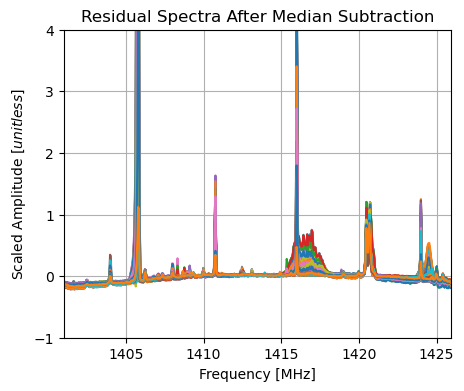

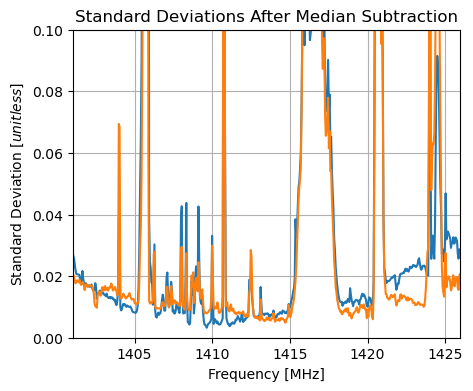

In [123]:
plt.rcParams['figure.figsize'] = [5, 4]

frequencies = normalized_spectra['frequencies'][0]/1e6

plt.figure()
for i in range(len(RHCP_med_removed)):
    plt.plot(frequencies,RHCP_med_removed[i])
    plt.plot(frequencies,LHCP_med_removed[i])

plt.title("Residual Spectra After Median Subtraction")
plt.ylim([-1,4])
plt.ylabel(r"Scaled Amplitude $[unitless]$")
plt.xlim([frequencies[0], frequencies[-1]])
plt.xlabel("Frequency [MHz]")
plt.grid()
plt.show()

plt.figure()

plt.plot(frequencies,RHCP_std)
plt.plot(frequencies,LHCP_std)

plt.title("Standard Deviations After Median Subtraction")
plt.ylim([0,0.1])
plt.ylabel(r"Standard Deviation $[unitless]$")
plt.xlim([frequencies[0], frequencies[-1]])
plt.xlabel("Frequency [MHz]")
plt.grid()
plt.show()

### throw out anything where the standard deviation is too high

in this case set threshold as more than 0.02

In [191]:
mean_std = (RHCP_std + LHCP_std)/2

good_indices = np.where(mean_std <= 0.02)
clean_frequencies = normalized_spectra['frequencies'][0][good_indices]
num_clean_frequencies = len(clean_frequencies)

In [192]:
RHCP_clean_data = []
LHCP_clean_data = []

for i in range(num_points):
    point = normalized_spectra.iloc[i]
    # just hard code this because it makes building the arrays a little easier
    RHCP_clean_data.append(point['RHCP'][:,good_indices])
    LHCP_clean_data.append(point['LHCP'][:,good_indices])


RHCP_clean_data = np.swapaxes(np.array(RHCP_clean_data),0,1).reshape(3,num_points, num_clean_frequencies)
LHCP_clean_data = np.swapaxes(np.array(LHCP_clean_data),0,1).reshape(3,num_points, num_clean_frequencies)

print(f" array shape: {np.shape(LHCP_clean_data)}")

 array shape: (3, 22, 366)


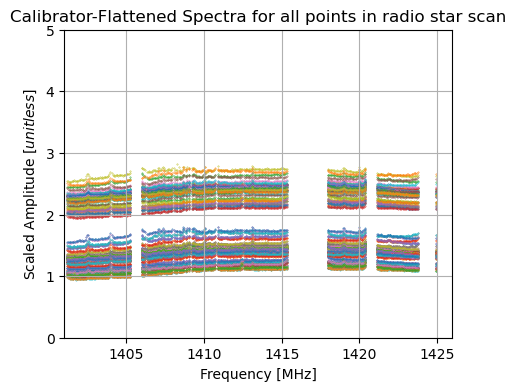

In [193]:
plt.figure()
for j in range(num_points):
    for i in range(3):
        plt.scatter(clean_frequencies/1e6,RHCP_clean_data[i][j],s=0.1)
        plt.scatter(clean_frequencies/1e6,LHCP_clean_data[i][j],s=0.1)
        #plt.plot(point_spectra['frequencies'][j]/1e6,point_spectra['LHCP'][j][i]/LHCP_cal)

plt.title("Calibrator-Flattened Spectra for all points in radio star scan")
plt.ylim([0,5])
plt.ylabel(r"Scaled Amplitude $[unitless]$")
plt.xlim([normalized_spectra.iloc[0]['frequencies'][0]/1e6, normalized_spectra.iloc[0]['frequencies'][-1]/1e6])
plt.xlabel("Frequency [MHz]")
plt.grid()
plt.show()


## 7. Initial Uncalibrated Broadband Curves

Plot the three arms of the radio star scan vs radius from the star to verify the response appears reasonable

In [194]:
#for some reason the pandas to_numpy() method dooesn't work here so need to forcibly get these into numpy arrays
#in hidsight perhaps it was a poor choice of data structure 

RHCP_data = []
LHCP_data = []
positions = []
position_times = []

for i in range(num_points):
    point = normalized_spectra.iloc[i]
    # just hard code this because it makes building the arrays a little easier
    RHCP_data.append(point['RHCP'])
    LHCP_data.append(point['LHCP'])
    positions.append(scan_points_info['pos'][i])
    position_times.append(scan_points_info['cal_1_bounds'][i][0])

RHCP_data = np.swapaxes(np.array(RHCP_data),0,1).reshape(3,num_points, num_frequency_points)
LHCP_data = np.swapaxes(np.array(LHCP_data),0,1).reshape(3,num_points, num_frequency_points)
positions = np.swapaxes(np.array(positions),0,1)
print(f" array shape: {np.shape(RHCP_data)}")

 array shape: (3, 22, 512)


In [344]:
radii = []

for pos in scan_points_info['pos']:
    #for RA, need to account for declination to get true degrees of arc)
    d_ra = (pos[0] - scan_center[0])*np.cos(np.deg2rad(pos[1]/2))
    d_dec = pos[1] - scan_center[1]
    radius = np.sqrt(d_ra**2 + d_dec**2)
    radii.append(radius)
    
radii=np.array(radii)
print(radii)


[7.00000000e-03 4.87886765e-01 1.22048258e+00 2.44006391e+00
 4.87924162e+00 7.31929381e+00 9.75847571e+00 3.56039161e-01
 8.86918397e-01 1.78252478e+00 3.61902683e+00 5.52618376e+00
 7.51492157e+00 3.43991058e-01 8.63720963e-01 1.72107764e+00
 3.40320314e+00 5.04733915e+00 6.65781763e+00 8.86918397e-01
 1.21961145e+00 8.64328518e-01]


### Plot RCHP and LHCP data to verify this all lines up right

Note that we can clearly see a strong slope in the response of the data which corresponds to a changing background level. 

In [345]:
RHCP_median = np.median(RHCP_data,axis=2)
LHCP_median = np.median(LHCP_data,axis=2)

RHCP_clean_median = np.median(RHCP_clean_data,axis=2)
LHCP_clean_median = np.median(LHCP_clean_data,axis=2)

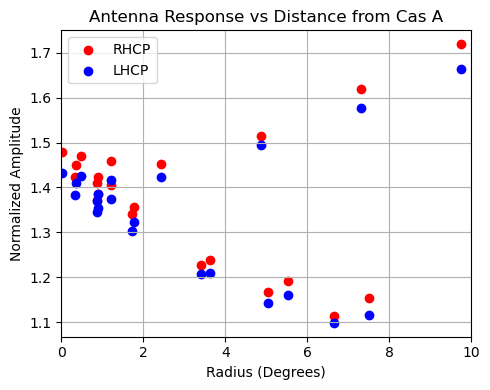

In [346]:
plt.rcParams['figure.figsize'] = [5, 4]

plt.figure()
#plt.scatter(radii, RHCP_median[0], color='red', label="RHCP")
#plt.scatter(radii, LHCP_median[0], color='blue', label="LHCP")
plt.scatter(radii, RHCP_clean_median[0], color='red', label="RHCP")
plt.scatter(radii, LHCP_clean_median[0], color='blue', label="LHCP")
plt.xlim([0,int(max(radii)+1)])
plt.title("Antenna Response vs Distance from Cas A")
plt.ylabel("Normalized Amplitude")
plt.xlabel("Radius (Degrees)")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

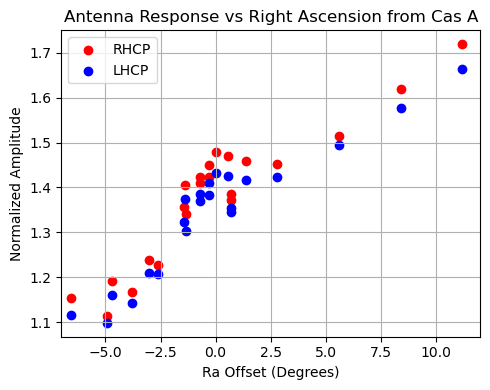

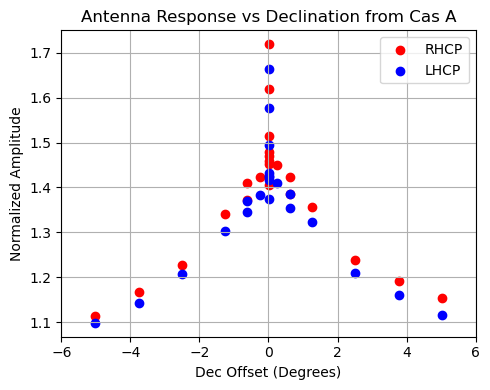

In [347]:
plt.rcParams['figure.figsize'] = [5, 4]

d_ra = positions[0] - scan_center[0]

plt.figure()
#plt.scatter(d_ra, RHCP_median[0], color='red', label="RHCP")
#plt.scatter(d_ra, LHCP_median[0], color='blue', label="LHCP")
plt.scatter(d_ra, RHCP_clean_median[0], color='red', label="RHCP")
plt.scatter(d_ra, LHCP_clean_median[0], color='blue', label="LHCP")
plt.xlim([int(min(d_ra)-1),int(max(d_ra)+1)])
plt.title("Antenna Response vs Right Ascension from Cas A")
plt.ylabel("Normalized Amplitude")
plt.xlabel("Ra Offset (Degrees)")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

d_dec = positions[1] - scan_center[1]

plt.figure()
plt.scatter(d_dec, RHCP_clean_median[0], color='red', label="RHCP")
plt.scatter(d_dec, LHCP_clean_median[0], color='blue', label="LHCP")
plt.xlim([int(min(d_dec)-1),int(max(d_dec)+1)])
plt.title("Antenna Response vs Declination from Cas A")
plt.ylabel("Normalized Amplitude")
plt.xlabel("Dec Offset (Degrees)")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

## 8. Plot antenna response vs elevation

Need to model antenna elevation change over the full measurement set so we can remove its influence from the measurement. Note that in this case the slope really is much too strong to plausibly be elevation related (especially given the telescope elevation at the time), so this is a real background slope and it's just coincidental that the elevation axis lines up with it well.

In [348]:
antenna_azels = []
for i in range(num_points):
    point = scan_points_info.iloc[i]
    pos = point['pos']
    point_time = point['cal_1_bounds'][0]
    azelvec = radec_to_azel(point_time.timestamp(), pos[0], 0.0, pos[1], 0.0)
    antenna_azels.append([azelvec['az_pos'], azelvec['el_pos']])
    
antenna_azels = np.swapaxes(np.array(antenna_azels),0,1)
print(np.shape(antenna_azels))

(2, 22)


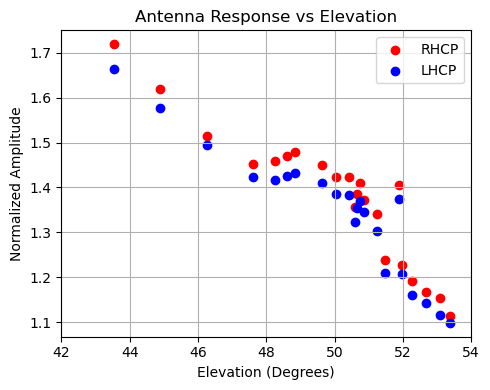

In [349]:
plt.rcParams['figure.figsize'] = [5, 4]

plt.figure()
plt.scatter(antenna_azels[1], RHCP_clean_median[0], color='red', label="RHCP")
plt.scatter(antenna_azels[1], LHCP_clean_median[0], color='blue', label="LHCP")
plt.xlim([int(min(antenna_azels[1])-1),int(max(antenna_azels[1])+1)])
plt.title("Antenna Response vs Elevation")
plt.ylabel("Normalized Amplitude")
plt.xlabel("Elevation (Degrees)")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

## 9. Compute and Plot Gain Correction vs Time 

We want to verify the calibrator response does not indicate any sort of constant gain drift across the measurement.

note that the fact there is any correlation at all between the two curves is a bit suspicious. on a longer timescale that is likely temperature dependent but on shorter timescales it may imply gin compression effects or RFI I'm doing a poor job of filtering out

In [350]:
RHCP_cal = RHCP_clean_data[1]- RHCP_clean_data[0]
LHCP_cal = LHCP_clean_data[2]- LHCP_clean_data[0]

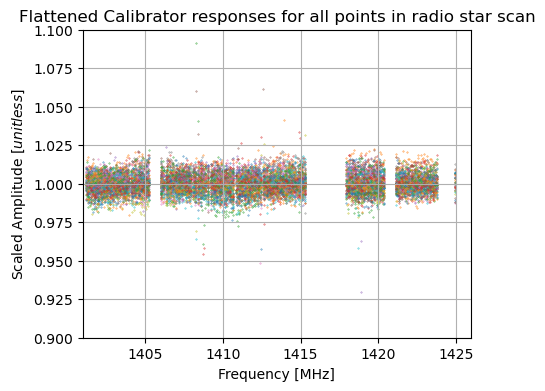

In [351]:
plt.rcParams['figure.figsize'] = [5, 4]

plt.figure()
for i in range(num_points):
    plt.scatter(clean_frequencies/1e6,RHCP_cal[i],s=0.1)
    plt.scatter(clean_frequencies/1e6,LHCP_cal[i],s=0.1)
        #plt.plot(point_spectra['frequencies'][j]/1e6,point_spectra['LHCP'][j][i]/LHCP_cal)

plt.title("Flattened Calibrator responses for all points in radio star scan")
plt.ylim([0.9,1.1])
plt.ylabel(r"Scaled Amplitude $[unitless]$")
plt.xlim([normalized_spectra.iloc[0]['frequencies'][0]/1e6, normalized_spectra.iloc[0]['frequencies'][-1]/1e6])
plt.xlabel("Frequency [MHz]")
plt.grid()
plt.show()

In [352]:
## calibrator median levels

RHCP_cal_median = np.median(RHCP_cal, axis=1)
LHCP_cal_median = np.median(LHCP_cal, axis=1)

## calibrator estimate error budget (this is a somewhat naive approach but is a reasonable starting point until we learn more about our performance)

used_BW = float(sr) * num_clean_frequencies / num_frequency_points

RHCP_calon_sigma = np.median(RHCP_clean_data[1],axis=1) / np.sqrt(used_BW * cal_time)
LHCP_calon_sigma = np.median(LHCP_clean_data[2],axis=1) / np.sqrt(used_BW * cal_time)

RHCP_obs_sigma = np.median(RHCP_clean_data[0],axis=1) / np.sqrt(used_BW * integration_time)
LHCP_obs_sigma = np.median(LHCP_clean_data[0],axis=1) / np.sqrt(used_BW * integration_time)

RHCP_cal_sigma = np.sqrt(RHCP_calon_sigma**2 + RHCP_obs_sigma**2)
LHCP_cal_sigma = np.sqrt(LHCP_calon_sigma**2 + LHCP_obs_sigma**2)


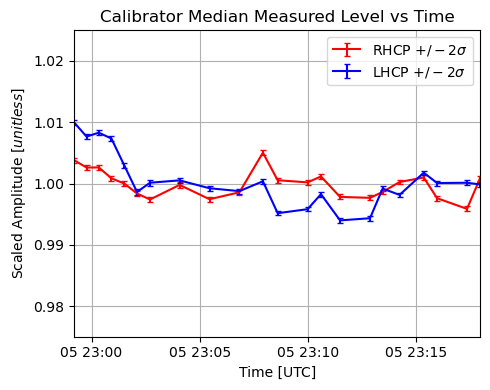

In [353]:
plt.rcParams['figure.figsize'] = [5, 4]

plt.figure()

#plt.scatter(position_times,RHCP_cal_median,color='red', label='RHCP', s=5)
#plt.scatter(position_times,LHCP_cal_median,color='blue', label='LHCP', s=5)

plt.errorbar(position_times, RHCP_cal_median, yerr=2*RHCP_cal_sigma, color='red', label=r'RHCP $+/- 2\sigma$', capsize=2.0)
plt.errorbar(position_times, LHCP_cal_median, yerr=2*LHCP_cal_sigma, color='blue', label=r'LHCP $+/- 2\sigma$', capsize=2.0)

plt.title("Calibrator Median Measured Level vs Time")
plt.ylim([0.975,1.025])
plt.ylabel(r"Scaled Amplitude $[unitless]$")
plt.xlim([position_times[0], position_times[-1]])
plt.xlabel("Time [UTC]")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

### Broadband Gain Corrections

In [354]:
RHCP_gain_correction = 1.0/RHCP_cal_median
LHCP_gain_correction = 1.0/LHCP_cal_median

RHCP_gain_error =  0.5/(RHCP_cal_median - RHCP_cal_sigma) - 0.5/(RHCP_cal_median + RHCP_cal_sigma)
LHCP_gain_error =  0.5/(LHCP_cal_median - LHCP_cal_sigma) - 0.5/(LHCP_cal_median + LHCP_cal_sigma)

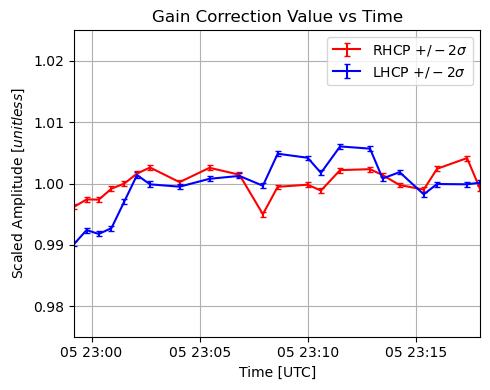

In [355]:
plt.rcParams['figure.figsize'] = [5, 4]

plt.figure()

#plt.scatter(position_times,RHCP_cal_median,color='red', label='RHCP', s=5)
#plt.scatter(position_times,LHCP_cal_median,color='blue', label='LHCP', s=5)

plt.errorbar(position_times, RHCP_gain_correction, yerr=2*RHCP_gain_error, color='red', label=r'RHCP $+/- 2\sigma$', capsize=2.0)
plt.errorbar(position_times, LHCP_gain_correction, yerr=2*LHCP_gain_error, color='blue', label=r'LHCP $+/- 2\sigma$', capsize=2.0)

plt.title("Gain Correction Value vs Time")
plt.ylim([0.975,1.025])
plt.ylabel(r"Scaled Amplitude $[unitless]$")
plt.xlim([position_times[0], position_times[-1]])
plt.xlabel("Time [UTC]")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

## 10. Fit Gain Corrected Data to Cas A* and Telescope Beam Profile

use a gaussian model for the telescope beam here since it's good enough for our purposes

In [356]:
import scipy.optimize as opt

### gaussian profile definition

In [357]:
def gaussian(x,y, var):
    return np.exp(-(x**2 + y**2)/(2*var))

def Beam_Response_Estimate(xy, xs, ys, xslope, yslope, source_level, background_level, source_diff, background_diff):
    """
    Estimate a fit for a gaussian on a flat background for two polarizations

    reason for doing it this way is to force a common pointing center estimate
    
    x,y coordinates
    xs, ys Centerpoint of gaussian
    xslope, yslope slope of background at gaussian location
    source_level = amplitude of source,
    background_level = background level at source location
    source_diff = difference in detected source level between the two polarizations
    background_diff = difference in detected background level between the two polarizations
    """

    #beam params
    beamwidth = 2.90 #degrees
    var = (beamwidth / 2.35)**2

    x, y = xy

    #fix coord frame distortion
    x_source = (x-xs)*np.cos(np.deg2rad(y/2))
    #x_source = (x-xs)*np.cos(np.deg2rad((y + ys)/2)) 
    y_source = y-ys

    #background level
    R_background = background_level + background_diff/2 + xslope * x_source + yslope*y_source
    L_background = background_level - background_diff/2 + xslope * x_source + yslope*y_source

    # gaussian
    R_source = (source_level+source_diff/2)*gaussian(x_source, y_source, var)
    L_source = (source_level-source_diff/2)*gaussian(x_source, y_source, var)

    #total
    RHCP_response = R_source + R_background
    LHCP_response = L_source + L_background
    response = np.array([RHCP_response, LHCP_response])

    return response.ravel()

### Generate initial guess and fit model

base initial guess on approx SEFD of telescope ~ 8 kJy within galactic plane

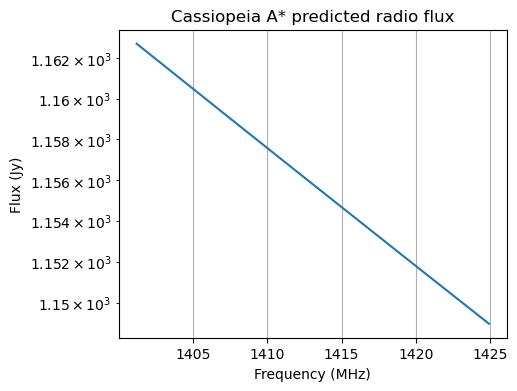

In [388]:
flux = get_flux('CassiopeiaA',clean_frequencies*u.Hz)*get_cas_A_C3(2025, clean_frequencies*u.Hz)

plt.figure()
plt.semilogy(clean_frequencies/1e6,flux)
plt.ylabel("Flux (Jy)")
plt.xlabel("Frequency (MHz)")
plt.title("Cassiopeia A* predicted radio flux")
plt.grid()
plt.show()

In [389]:
SEFD_initial = 8000*u.Jy
med_flux = np.median(get_flux('CassiopeiaA',clean_frequencies*u.Hz)*get_cas_A_C3(2025, clean_frequencies*u.Hz))
print(med_flux)

normalized_source_level = med_flux/SEFD_initial
normalized_background_level = 1.0

initial_guess = (radio_stars['CassiopeiaA']['coords'][0], #Right Ascension
                 radio_stars['CassiopeiaA']['coords'][1], #Declination
                 0, #RA slope
                 0, #Dec slope
                 normalized_source_level, #expected source response
                 normalized_background_level, #expected background response
                 0, #difference between source level seen by the two polarizations
                 0, #difference between background levels seen by the two polarizations
                )

print(f"coords: RA = {initial_guess[0]}, Dec = {initial_guess[1]}")
print(f"background slopes: RA slope = {initial_guess[2]}, Dec slope = {initial_guess[3]}")
print(f"RHCP source level = {initial_guess[4] + initial_guess[6]/2}")
print(f"LHCP source level = {initial_guess[4] - initial_guess[6]/2}")
print(f"RHCP background level = {initial_guess[5] + initial_guess[7]/2}")
print(f"LHCP background level = {initial_guess[5] - initial_guess[7]/2}")

1156.687197348213 Jy
coords: RA = 350.8584, Dec = 58.8113
background slopes: RA slope = 0, Dec slope = 0
RHCP source level = 0.1445858996685266
LHCP source level = 0.1445858996685266
RHCP background level = 1.0
LHCP background level = 1.0


### Perform Fit

It's worth noting that we can be a bit clever in checking whether we trust the calibrator correction here. Ideally, the error estimates in the fit should be lower with the correction if it helps. in the case of the test data, this is in fact the case. 

In the absence of the gain correction, the first test on cas A yields the following estimate

coords: RA = 350.1036, Dec = 58.8884, vars = 0.0182, 0.0167\
background slopes: RA slope = 0.0393, Dec slope = 0.0068, vars = 0.0000009, 0.0000016\
RHCP source level = 0.1329, var = 0.000138\
LHCP source level = 0.1223, var = 0.000135\
RHCP background level = 1.3029, var = 0.000055\
LHCP background level = 1.2737, var = 0.00005

With the gain correction, we get the following. Most of the variances are reduced slightly, despite the larger variance of the corrected data as input, implying that we have removed at least a small amount of noise from the measurement.

coords: RA = 350.0070, Dec = 58.8573, vars = 0.0152, 0.0133\
background slopes: RA slope = 0.0393, Dec slope = 0.0070, vars = 0.0000007, 0.0000015\
RHCP source level = 0.1362, var = 0.000119\
LHCP source level = 0.1236, var = 0.000117\
RHCP background level = 1.2994, var = 0.000046\
LHCP background level = 1.2702, var = 0.000045

In [390]:
x = positions[0]
y = positions[1]

#rpopt, rpcov = opt.curve_fit(Beam_Response_Estimate, (x,y), (RHCP_clean_median[0]), p0 = initial_guess, sigma = RHCP_obs_sigma)
#lpopt, lpcov = opt.curve_fit(Beam_Response_Estimate, (x,y), (LHCP_clean_median[0]), p0 = initial_guess, sigma = LHCP_obs_sigma)

#rpopt, rpcov = opt.curve_fit(Beam_Response_Estimate, (x,y), (RHCP_clean_median[0] * RHCP_gain_correction), p0 = initial_guess, sigma = RHCP_gain_error + RHCP_obs_sigma)
#lpopt, lpcov = opt.curve_fit(Beam_Response_Estimate, (x,y), (LHCP_clean_median[0] * LHCP_gain_correction), p0 = initial_guess, sigma = LHCP_gain_error + LHCP_obs_sigma)

#popt, pcov = opt.curve_fit(
#                        Beam_Response_Estimate, 
#                        (x,y), 
#                        np.array([RHCP_clean_median[0],
#                                  LHCP_clean_median[0]]).ravel(), 
#                        p0 = initial_guess, 
#                        sigma = np.array([RHCP_obs_sigma, LHCP_obs_sigma]).ravel())

popt, pcov = opt.curve_fit(
                        Beam_Response_Estimate, 
                        (x,y), 
                        np.array([RHCP_clean_median[0] * RHCP_gain_correction,
                                  LHCP_clean_median[0] * LHCP_gain_correction]).ravel(), 
                        p0 = initial_guess, 
                        sigma = np.array([RHCP_gain_error + RHCP_obs_sigma, LHCP_gain_error + LHCP_obs_sigma]).ravel())

In [391]:
print(f"coords: RA = {popt[0]:.4f}, Dec = {popt[1]:.4f}, vars = {pcov[0,0]:.4f}, {pcov[1,1]:.4f}")
print(f"background slopes: RA slope = {popt[2]:.4f}, Dec slope = {popt[3]:.4f}, vars = {pcov[2,2]:.7f}, {pcov[3,3]:.7f}")
print(f"RHCP source level = {(popt[4]+popt[6]/2):.4f}, var = {(pcov[4,4]+pcov[6,6]/4 + 0.5*pcov[4,6]):.6f}")
print(f"LHCP source level = {(popt[4]-popt[6]/2):.4f}, var = {(pcov[4,4]+pcov[6,6]/4 - 0.5*pcov[4,6]):.6f}")
print(f"RHCP background level = {(popt[5]+popt[7]/2):.4f}, var = {(pcov[5,5]+pcov[7,7]/4 + 0.5*pcov[5,7]):.6f}")
print(f"LHCP background level = {(popt[5]-popt[7]/2):.4f}, var = {(pcov[5,5]+pcov[7,7]/4 - 0.5*pcov[5,7]):.6f}")

coords: RA = 350.0070, Dec = 58.8573, vars = 0.0152, 0.0133
background slopes: RA slope = 0.0393, Dec slope = 0.0070, vars = 0.0000007, 0.0000015
RHCP source level = 0.1362, var = 0.000119
LHCP source level = 0.1236, var = 0.000117
RHCP background level = 1.2994, var = 0.000046
LHCP background level = 1.2702, var = 0.000045


### Reproduse input datea from model fit

In [392]:
x = positions[0]
y = positions[1]

beam_responses = Beam_Response_Estimate((x,y), *popt).reshape(2,-1)
RHCP_model = beam_responses[0]
LHCP_model = beam_responses[1]

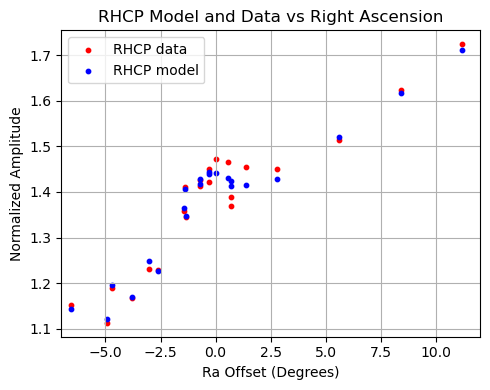

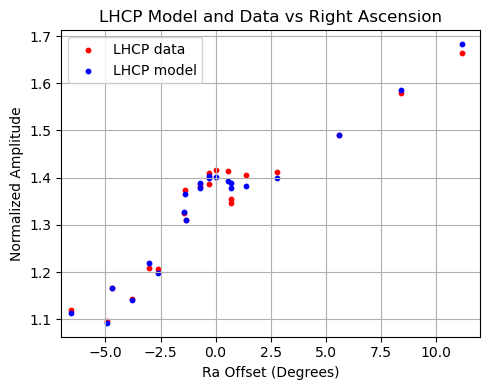

In [393]:
plt.rcParams['figure.figsize'] = [5, 4]

d_ra = positions[0] - scan_center[0]

plt.figure()
plt.scatter(d_ra, RHCP_clean_median[0]* RHCP_gain_correction, color='red', label="RHCP data", s=10)
plt.scatter(d_ra, RHCP_model, color='blue', label="RHCP model", s=10)
#plt.scatter(d_dec, LHCP_clean_median[0], color='blue', label="LHCP")
plt.xlim([int(min(d_ra)-1),int(max(d_ra)+1)])
plt.title("RHCP Model and Data vs Right Ascension")
plt.ylabel("Normalized Amplitude")
plt.xlabel("Ra Offset (Degrees)")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

plt.figure()
plt.scatter(d_ra, LHCP_clean_median[0]* LHCP_gain_correction, color='red', label="LHCP data", s=10)
plt.scatter(d_ra, LHCP_model, color='blue', label="LHCP model", s=10)
#plt.scatter(d_dec, LHCP_clean_median[0], color='blue', label="LHCP")
plt.xlim([int(min(d_ra)-1),int(max(d_ra)+1)])
plt.title("LHCP Model and Data vs Right Ascension")
plt.ylabel("Normalized Amplitude")
plt.xlabel("Ra Offset (Degrees)")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

## 11. Average SEFD Estimation

get SEFD from source flux and Y factors by just taking SEFD = flux/(Y-1)

In [394]:
source_levels = np.array([(popt[4]+popt[6]/2), (popt[4]-popt[6]/2)])
source_vars = np.array([(pcov[4,4]+pcov[6,6]/4 + 0.5*pcov[4,6]), (pcov[4,4]+pcov[6,6]/4 - 0.5*pcov[4,6])])
background_levels = np.array([(popt[5]+popt[7]/2),(popt[5]-popt[7]/2)])
background_vars = np.array([(pcov[5,5]+pcov[7,7]/4 + 0.5*pcov[5,7]),(pcov[5,5]+pcov[7,7]/4 - 0.5*pcov[5,7])])

Y = source_levels / background_levels + 1
Y_var = (source_levels / (background_levels - background_vars)  - source_levels / (background_levels + background_vars))*0.5

SEFD =  med_flux / (Y-1)
print(Y)
print(Y_var)
print(SEFD)

[1.10481513 1.09732419]
[3.68477108e-06 3.46992758e-06]
[11035.49867655 11884.88955015] Jy
